In [1]:
import numpy as np

import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'savefig.dpi':300,  
})

In [2]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('gpt2')

c:\Users\PauloOliveira\py_studies\ml4llm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sentences = [
    ['English',   "In Penny Lane, there is a barber showing photographs of every head he's had the pleasure to have known. And all the people that come and go stop and say hello."],
    ['Spanish',   "En Penny Lane hay un barbero que muestra fotografías de todas las personas que ha tenido el placer de conocer. Y todas las personas que van y vienen se detienen y dicen hola."],
    ['Arabic',    "في شارع بيني لين، يوجد حلاق يعرض صورًا لكل شخص كان له شرف معرفته. وكل الناس الذين يأتون ويذهبون يتوقفون ويقولون مرحبًا."],
    ['Persian',   "در خیابان پنی لین، یک آرایشگر وجود دارد که عکس‌های تمام افرادی را که افتخار آشنایی با آن‌ها را داشته به نمایش می‌گذارد. و همهٔ کسانی که می‌آیند و می‌روند می‌ایستند و سلام می‌کنند."],
    ['Lithuanian',"Penny Lane gatvėje yra kirpėjas, rodantis nuotraukas visų žmonių, kuriuos jam teko su malonumu pažinti. Ir visi žmonės, kurie ateina ir išeina, sustoja ir pasisveikina."],
    ['Chinese',   "在彭尼巷，有一位理发师正在展示他曾有幸认识的每一个人的照片。所有来来往往的人都会停下来打招呼。"],
    ['Tamil',     "பென்னி லேனில், தான் அறிந்த ஒவ்வொருவரையும் அறிந்ததற்கான மகிழ்ச்சியுடன் அவர்களின் புகைப்படங்களை காட்டும் ஒரு முடி திருத்துபவர் இருக்கிறார். வரவும் போகவும் 하는 அனைத்து மக்களும் நின்று வணக்கம் சொல்கிறார்கள்."],
    ['Hebrew',    "בפני ליין יש ספר שמציג תמונות של כל אדם שהיה לו העונג להכיר. וכל האנשים שבאים והולכים עוצרים ואומרים שלום."],
            ]

In [4]:
tokenCount = []
charsCount = []
bytesCount = []
table = ''

for lang, text in sentences:

    tokens = tokenizer.encode(text)
    print(f'{lang:>10}: {tokenizer.decode(tokens)}')

    tokenCount.append(len(tokens))
    charsCount.append(len(text))
    bytesCount.append(len(text.encode('utf-8')))

    table += f'{lang:>10} |   {charsCount[-1]:3}   |   {bytesCount[-1]:3}   |  {tokenCount[-1]:3}\n'

   English: In Penny Lane, there is a barber showing photographs of every head he's had the pleasure to have known. And all the people that come and go stop and say hello.
   Spanish: En Penny Lane hay un barbero que muestra fotografías de todas las personas que ha tenido el placer de conocer. Y todas las personas que van y vienen se detienen y dicen hola.
    Arabic: في شارع بيني لين، يوجد حلاق يعرض صورًا لكل شخص كان له شرف معرفته. وكل الناس الذين يأتون ويذهبون يتوقفون ويقولون مرحبًا.
   Persian: در خیابان پنی لین، یک آرایشگر وجود دارد که عکس‌های تمام افرادی را که افتخار آشنایی با آن‌ها را داشته به نمایش می‌گذارد. و همهٔ کسانی که می‌آیند و می‌روند می‌ایستند و سلام می‌کنند.
Lithuanian: Penny Lane gatvėje yra kirpėjas, rodantis nuotraukas visų žmonių, kuriuos jam teko su malonumu pažinti. Ir visi žmonės, kurie ateina ir išeina, sustoja ir pasisveikina.
   Chinese: 在彭尼巷，有一位理发师正在展示他曾有幸认识的每一个人的照片。所有来来往往的人都会停下来打招呼。
     Tamil: பென்னி லேனில், தான் அறிந்த ஒவ்வொருவரையும் அறிந்ததற்கான மகிழ்ச்சி

In [5]:
print(' Language  |  Chars  |  Bytes  |  Tokens ')
print('-----------+---------+---------+---------')
print(table)

 Language  |  Chars  |  Bytes  |  Tokens 
-----------+---------+---------+---------
   English |   159   |   159   |   36
   Spanish |   174   |   175   |   61
    Arabic |   119   |   215   |  130
   Persian |   179   |   330   |  215
Lithuanian |   168   |   177   |   84
   Chinese |    47   |   141   |   94
     Tamil |   202   |   558   |  557
    Hebrew |   106   |   191   |  122



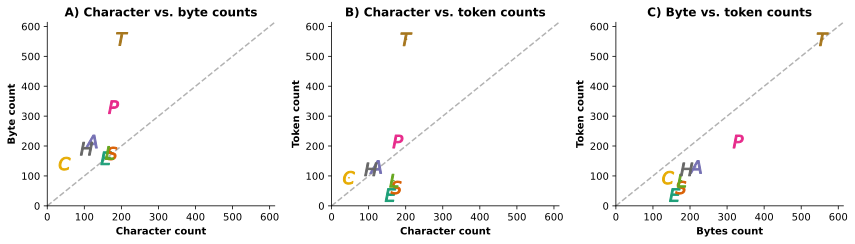

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(12,3.5))

maxCount = 1.1 * np.max([np.max(charsCount), np.max(bytesCount), np.max(tokenCount)])

for i in range(len(sentences)):

    langMark = rf'${sentences[i][0][0]}$'

    axs[0].plot(charsCount[i],bytesCount[i],marker=langMark, markersize=13,color=plt.cm.Dark2(i/len(sentences)))

    axs[1].plot(charsCount[i],tokenCount[i],marker=langMark, markersize=13,color=plt.cm.Dark2(i/len(sentences)))

    axs[2].plot(bytesCount[i],tokenCount[i],marker=langMark, markersize=13,color=plt.cm.Dark2(i/len(sentences)))

for a in axs:
  
  a.plot([0,maxCount],[0,maxCount], '--',color=[.7,.7,.7],zorder=-23)

axs[0].set(xlabel='Character count',ylabel='Byte count',xlim=[0,maxCount],ylim=[0,maxCount], title='A) Character vs. byte counts')
axs[1].set(xlabel='Character count',ylabel='Token count',xlim=[0,maxCount],ylim=[0,maxCount], title='B) Character vs. token counts')
axs[2].set(xlabel='Bytes count',ylabel='Token count',xlim=[0,maxCount],ylim=[0,maxCount], title='C) Byte vs. token counts')

plt.tight_layout()
plt.savefig('ch2_proj6_part2.png')
plt.show()